# 项目：用逻辑回归预测泰坦尼克号幸存情况

## 1. 分析目标

此数据分析报告的目的是，基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。

## 2. 简介

> 泰坦尼克号（英语：RMS Titanic）是一艘奥林匹克级邮轮，于1912年4月首航时撞上冰山后沉没。泰坦尼克号是同级的3艘超级邮轮中的第2艘，与姐妹船奥林匹克号和不列颠号为白星航运公司的乘客们提供大西洋旅行。

> 泰坦尼克号由位于北爱尔兰贝尔法斯特的哈兰·沃尔夫船厂兴建，是当时最大的客运轮船，由于其规模相当一艘现代航空母舰，因而号称“上帝也沉没不了的巨型邮轮”。在泰坦尼克号的首航中，从英国南安普敦出发，途经法国瑟堡-奥克特维尔以及爱尔兰昆士敦，计划横渡大西洋前往美国纽约市。但因为人为错误，于1912年4月14日船上时间夜里11点40分撞上冰山；2小时40分钟后，即4月15日凌晨02点20分，船裂成两半后沉入大西洋，死亡人数超越1500人，堪称20世纪最大的海难事件，同时也是最广为人知的海难之一。

数据集包括两个数据表：`titianic_train.csv`和`titanic_test.csv`。

`titianic_train.csv`记录了超过八百位泰坦尼克号乘客在沉船事件后的幸存情况，以及乘客的相关信息，包括所在船舱等级、性别、年龄、同乘伴侣/同胞数量、同乘父母/孩子数量，等等。

`titanic_test.csv`只包含乘客（这些乘客不在`titianic_train.csv`里）相关信息，此文件可以被用于预测乘客是否幸存。

`titianic_train.csv`每列的含义如下：
- PassengerId：乘客ID
- survival：是否幸存
   - 0	否
   - 1	是
- pclass：船舱等级
   - 1	一等舱
   - 2	二等舱
   - 3  三等舱
- sex：性别
- Age：年龄
- sibsp：同乘伴侣/同胞数量
- parch：同乘父母/孩子数量
- ticket：船票号
- fare：票价金额
- cabin：船舱号
- embarked：登船港口
   - C  瑟堡
   - Q  皇后镇
   - S  南安普敦
   
   
`titianic_test.csv`每列的含义和上面相同，但不具备survival变量的数据，即是否幸存。  


    

## 3. 数据分析前准备
### 3.1 导入数据库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### 3.2 设置图像字体

In [2]:
import matplotlib
matplotlib.rc("font",family=' Microsoft YaHei')

### 3.3 读取数据

In [3]:
original_data=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\数据分析集\泰坦尼克-逻辑回归\titanic_train.csv")
new_observation=pd.read_csv(r"C:\Users\ZhuanZ（无密码）\Desktop\数据分析集\泰坦尼克-逻辑回归\titanic_test.csv")

## 4. 数据评估和清理
结构问题判断：每个变量是否为一列，每个观察值是否为一行，每种类型的观察值是否为一个单元格  
内容问题判断：有无丢失数据、重复数据、不一致数据、无效或错误数据

### 4.1 结构问题

In [4]:
clean_data=original_data.copy()
clean_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


从头部的10行数据来看，数据符合“每行是同一个观察者，每列是同一个变量，每个单元格是一个值”，因此不存在结构性问题。

### 4.2 内容问题

In [5]:
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


#### 问题一
1. PassengerId类型应为str，Pclass、Sex、Embarked类型应为category
2. Age、Cabin、Embarked存在缺失数据

#### 4.2.1 类型转换

In [6]:
clean_data["PassengerId"]=clean_data["PassengerId"].astype(str)
clean_data["Pclass"]=clean_data["Pclass"].astype("category")
clean_data["Sex"]=clean_data["Sex"].astype("category")
clean_data["Embarked"]=clean_data["Embarked"].astype("category")
clean_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    str     
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
dtypes: category(3), float64(2), int64(3), str(4)
memory usage: 65.5 KB


#### 4.2.2 缺失数据处理

In [7]:
clean_data[clean_data["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


有177条观察值的年龄变量缺失，占总体数据比例20%左右,最好保留这些行,用乘客年龄平均值代替。

In [8]:
clean_data.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
clean_data["Age"].mean()

np.float64(29.69911764705882)

In [10]:
clean_data["Age"]=clean_data["Age"].fillna(clean_data["Age"].mean())
clean_data["Age"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [11]:
clean_data["Age"].mean()

np.float64(29.69911764705882)

In [12]:
clean_data[clean_data["Cabin"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


有687条观察值的船舱号变量缺失，缺失较大，所以不能删除这些观察值。
此外，船舱号并不是影响生还概率的关键因素，不会被纳入逻辑回归的自变量内，即使缺失也不会影响建立模型，因此可以保留这些观察值。

In [13]:
clean_data[clean_data["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


仅有两条观察值的登船港口变量缺失，登船港口并不是影响生还概率的关键因素，不会被纳入逻辑回归的自变量内，即使缺失也不会影响建立模型，因此可以保留这些观察值。

#### 4.2.3  重复数据处理
PassengerId是乘客的唯一标识符，不应该存在重复

In [14]:
clean_data["PassengerId"].duplicated().sum()

np.int64(0)

输出结果为0，说明不存在重复值

#### 4.2.4 不一致数据处理
分类数据可能纯在不一致性

In [15]:
clean_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [16]:
clean_data["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [17]:
clean_data["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [18]:
clean_data["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

从以上输出结果来看，均不存在不一致数据。

#### 无效或错误数据处理

In [19]:
clean_data.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,13.002015,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
clean_data["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [21]:
clean_data["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [22]:
clean_data[clean_data["Fare"]==0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.000000,0,0,LINE,0.0,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.000000,0,0,112059,0.0,B94,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.000000,0,0,LINE,0.0,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,29.699118,0,0,239853,0.0,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.000000,0,0,LINE,0.0,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,29.699118,0,0,239853,0.0,NaN,S
466,467,0,2,"Campbell, Mr. William",male,29.699118,0,0,239853,0.0,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,29.699118,0,0,239854,0.0,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.000000,0,0,LINE,0.0,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,29.699118,0,0,112052,0.0,NaN,S


乘客年龄平均为29.7岁左右，最大值为80岁，最小值为0.42岁；  
同乘伴侣/同胞数量最大值为8个，最小为0个,且数值正常；  
同乘父母/孩子数量最大值为6个，最小值为0个,且数值正常；  
船票价格平均为32元，最大值为512元，最小值为0元，猜测0元表示增票。  
数据不存在脱离现实的数值

## 5. 整理数据
数据变量包含乘客同乘伴侣/同胞数量，以及同乘父母/孩子数量，这些可以帮助计算出船上家庭成员的数量。我们对同乘家庭成员数量是否会显著影响幸存感兴趣，因此可以创建一个新的变量，记录这一数值。

In [23]:
clean_data["FamilyNum"]=clean_data["SibSp"]+clean_data["Parch"]
clean_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,0
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C,1


## 6. 探索数据
逻辑回归分析前，借助数据可视化，探索数值变量的分布，以及与乘客是否幸存存在相关性的变量，为后续的进一步分析提供方向。

### 6.1 幸存概率与船舱等级/性别的关系

In [24]:
Pclass_survived=clean_data.groupby(["Pclass"])["Survived"].mean()
Pclass_survived=Pclass_survived.reset_index()
Pclass_survived["Pclass"]=Pclass_survived["Pclass"].astype(str)
Pclass_survived["Pclass"]=Pclass_survived["Pclass"].replace({"1":"Pclass1","2":"Pclass2","3":"Pclass3"})
Pclass_survived

,Pclass,Survived
0,Pclass1,0.629630
1,Pclass2,0.472826
2,Pclass3,0.242363


Text(0.5, 0, '  ')

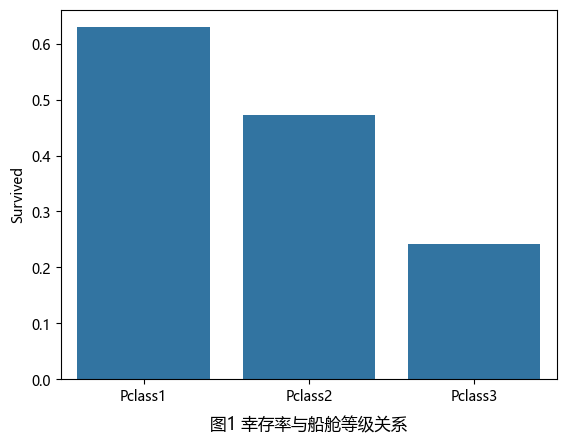

In [25]:
sns.barplot(x=Pclass_survived["Pclass"],y=Pclass_survived["Survived"])
plt.title("图1 幸存率与船舱等级关系",y=-0.16)
plt.xlabel("  ")   

In [26]:
Pclass_survived=clean_data.groupby(["Pclass","Sex"])["Survived"].mean()
Pclass_survived=Pclass_survived.reset_index()
Pclass_survived["Pclass"]=Pclass_survived["Pclass"].astype(str)
Pclass_survived["Pclass"]=Pclass_survived["Pclass"].replace({"1":"Pclass1","2":"Pclass2","3":"Pclass3"})
Pclass_survived

,Pclass,Sex,Survived
0,Pclass1,female,0.968085
1,Pclass1,male,0.368852
2,Pclass2,female,0.921053
3,Pclass2,male,0.157407
4,Pclass3,female,0.500000
5,Pclass3,male,0.135447


In [27]:
Pclass=clean_data["Pclass"].value_counts()
Pclass

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [28]:
Pclass=clean_data.groupby(["Pclass","Sex"])["PassengerId"].count()
Pclass=Pclass.reset_index()
Pclass["Sex"]=Pclass["Sex"].astype(str)
Pclass["Pclass"]=Pclass["Pclass"].astype(str)
Pclass

,Pclass,Sex,PassengerId
0,1,female,94
1,1,male,122
2,2,female,76
3,2,male,108
4,3,female,144
5,3,male,347


In [29]:
Pclass["new_pclass"]=Pclass["Sex"].str.cat(Pclass["Pclass"],sep="-")
Pclass["Pclass"]=Pclass["Pclass"].replace({"1":"Pclass1","2":"Pclass2","3":"Pclass3"})
Pclass

,Pclass,Sex,PassengerId,new_pclass
0,Pclass1,female,94,female-1
1,Pclass1,male,122,male-1
2,Pclass2,female,76,female-2
3,Pclass2,male,108,male-2
4,Pclass3,female,144,female-3
5,Pclass3,male,347,male-3


Text(0.5, 0, '  ')

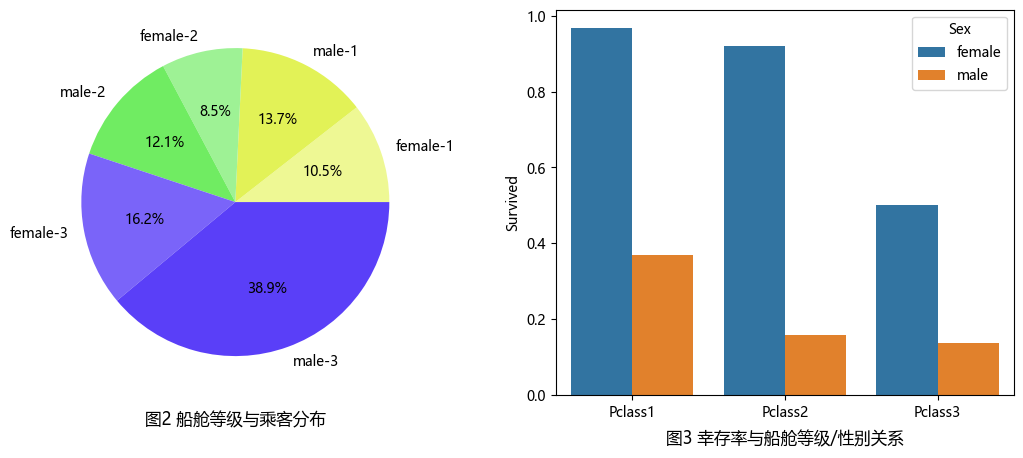

In [30]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].pie(Pclass["PassengerId"],labels=Pclass["new_pclass"],colors=['#EEF894','#E2F257','#9EF295','#70EC62','#7A64F9','#5A3FF8'],autopct="%.1f%%")
axes[0].set_title("图2 船舱等级与乘客分布",y=-0.1)
sns.barplot(x=Pclass_survived["Pclass"],y=Pclass_survived["Survived"],hue=Pclass_survived["Sex"],ax=axes[1])
axes[1].set_title("图3 幸存率与船舱等级/性别关系",y=-0.15)
plt.xlabel("  ")   

#### 6.1.1 船舱等级与乘客分布之间关系：
1. 图2可知，乘客主要集中在3等舱（55%），1、2等舱乘客数量相差不大（24%、21%）
2. 图2可知，乘客中约65%为男性，其中3等舱男性约为女性的两倍，1、2等舱乘客性别相对均衡

#### 6.1.2 幸存率与船舱等级/性别之间关系：
1. 图1可知，船舱等级越低的乘客中存活率越低（62.96% → 47.28% → 24.23%）
2. 图3可知，男性存活率远低于女性。其中，1等舱约低60个百分点，2等舱约低76个百分点，3等舱约低37个百分点；
3. 图3可知，1、2等舱女性存活率差距（96.81%,92.11%）不大，但远高于3等舱女性(50.00%)，约高出40个百分点；
4. 图3可知，2、3等舱男性存活率差距（15.74%,13.54%）不大，但低于1等舱男性(36.89%),生存概率仅为其二分之一；

### 6.2 幸存概率与年龄/性别的关系
对年龄进行分组，以7年也一个单位，0-7，7-14，14-21，21-28，28-35，35-42，42-49，49-56，56-63，63-70，70-77，77-84

In [31]:
box=[0,7,14,21,35,56,84]
label=["幼儿(0-7)","儿童(7-14)","少年(14-21)","青年(21-35)","中年(35-56)","老年(56-84)"]
customer_old=pd.cut(clean_data["Age"],box,labels=label,right=False)
customer_old

0      青年(21-35)
1      中年(35-56)
2      青年(21-35)
3      中年(35-56)
4      中年(35-56)
         ...    
886    青年(21-35)
887    少年(14-21)
888    青年(21-35)
889    青年(21-35)
890    青年(21-35)
Name: Age, Length: 891, dtype: category
Categories (6, str): ['幼儿(0-7)' < '儿童(7-14)' < '少年(14-21)' < '青年(21-35)' < '中年(35-56)' < '老年(56-84)']

In [32]:
customer_old_num=customer_old.value_counts()
customer_old_num

Age
青年(21-35)    476
中年(35-56)    196
少年(14-21)    109
幼儿(0-7)       47
老年(56-84)     39
儿童(7-14)      24
Name: count, dtype: int64

In [33]:
clean_old=clean_data.copy()
clean_old["Age"]=customer_old
clean_old[clean_old["Age"]=="幼儿(0-7)"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
7,8,0,3,"Palsson, Master. Gosta Leonard",male,幼儿(0-7),3,1,349909,21.0750,NaN,S,4
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,幼儿(0-7),1,1,PP 9549,16.7000,G6,S,2
16,17,0,3,"Rice, Master. Eugene",male,幼儿(0-7),4,1,382652,29.1250,NaN,Q,5
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,幼儿(0-7),1,2,SC/Paris 2123,41.5792,NaN,C,3
58,59,1,2,"West, Miss. Constance Mirium",female,幼儿(0-7),1,2,C.A. 34651,27.7500,NaN,S,3
63,64,0,3,"Skoog, Master. Harald",male,幼儿(0-7),3,2,347088,27.9000,NaN,S,5
78,79,1,2,"Caldwell, Master. Alden Gates",male,幼儿(0-7),0,2,248738,29.0000,NaN,S,2
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,幼儿(0-7),4,2,347082,31.2750,NaN,S,6
164,165,0,3,"Panula, Master. Eino Viljami",male,幼儿(0-7),4,1,3101295,39.6875,NaN,S,5
171,172,0,3,"Rice, Master. Arthur",male,幼儿(0-7),4,1,382652,29.1250,NaN,Q,5


In [34]:
clean_old[(clean_old["Age"]=="儿童(7-14)")&(clean_old["Sex"]=="female")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
24,25,0,3,"Palsson, Miss. Torborg Danira",female,儿童(7-14),3,1,349909,21.0750,NaN,S,4
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,儿童(7-14),2,2,W./C. 6608,34.3750,NaN,S,4
237,238,1,2,"Collyer, Miss. Marjorie ""Lottie""",female,儿童(7-14),0,2,C.A. 31921,26.2500,NaN,S,2
419,420,0,3,"Van Impe, Miss. Catharina",female,儿童(7-14),0,2,345773,24.1500,NaN,S,2
446,447,1,2,"Mellinger, Miss. Madeleine Violet",female,儿童(7-14),0,1,250644,19.5000,NaN,S,1
535,536,1,2,"Hart, Miss. Eva Miriam",female,儿童(7-14),0,2,F.C.C. 13529,26.2500,NaN,S,2
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,儿童(7-14),4,2,347082,31.2750,NaN,S,6
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,儿童(7-14),4,2,347082,31.2750,NaN,S,6
634,635,0,3,"Skoog, Miss. Mabel",female,儿童(7-14),3,2,347088,27.9000,NaN,S,5
780,781,1,3,"Ayoub, Miss. Banoura",female,儿童(7-14),0,0,2687,7.2292,NaN,C,0


In [35]:
clean_old.groupby(["Age","Sex"])["PassengerId"].count()

Age        Sex   
幼儿(0-7)    female     23
           male       24
儿童(7-14)   female     11
           male       13
少年(14-21)  female     43
           male       66
青年(21-35)  female    156
           male      320
中年(35-56)  female     72
           male      124
老年(56-84)  female      9
           male       30
Name: PassengerId, dtype: int64

In [36]:
old_survived=clean_old.groupby(["Age"])["Survived"].mean()
old_survived=old_survived.reset_index()
old_survived

,Age,Survived
0,幼儿(0-7),0.702128
1,儿童(7-14),0.375000
2,少年(14-21),0.366972
3,青年(21-35),0.348739
4,中年(35-56),0.418367
5,老年(56-84),0.307692


Text(0.5, 0, '  ')

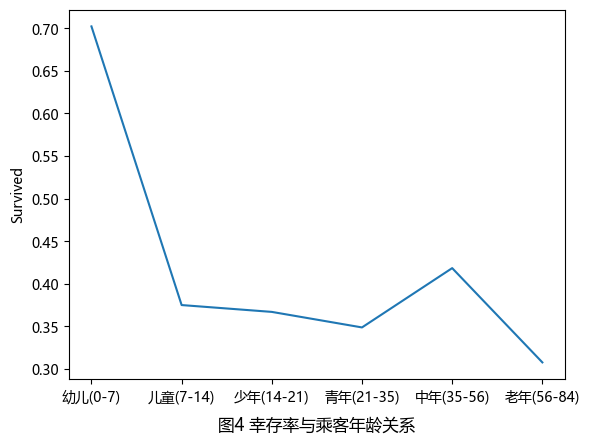

In [37]:
sns.lineplot(old_survived,x=old_survived["Age"],y=old_survived["Survived"])
plt.title("图4 幸存率与乘客年龄关系",y=-0.16)
plt.xlabel("  ")

In [38]:
old_survived=clean_old.groupby(["Age","Sex"])["Survived"].mean()
old_survived=old_survived.reset_index()
old_survived

,Age,Sex,Survived
0,幼儿(0-7),female,0.739130
1,幼儿(0-7),male,0.666667
2,儿童(7-14),female,0.363636
3,儿童(7-14),male,0.384615
4,少年(14-21),female,0.744186
5,少年(14-21),male,0.121212
6,青年(21-35),female,0.737179
7,青年(21-35),male,0.159375
8,中年(35-56),female,0.791667
9,中年(35-56),male,0.201613


Text(0.5, 0, '  ')

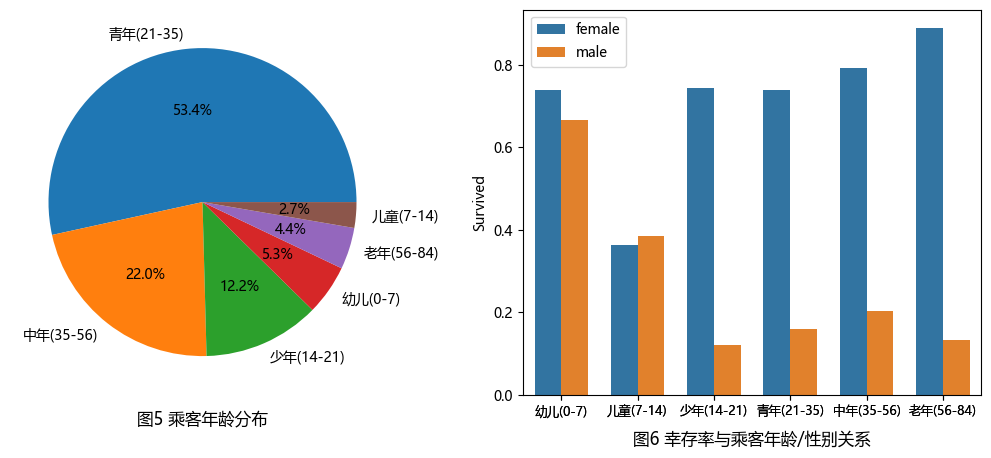

In [39]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].pie(customer_old_num,labels=customer_old_num.index,autopct="%.1f%%")
axes[0].set_title("图5 乘客年龄分布",y=-0.1)
sns.barplot(x=old_survived["Age"],y=old_survived["Survived"],hue=old_survived["Sex"],width=0.7,ax=axes[1])
axes[1].set_title("图6 幸存率与乘客年龄/性别关系",y=-0.15)
axes[1].legend(bbox_to_anchor=(0.24,1))
plt.xticks(old_survived["Age"],fontsize=9)
plt.xlabel("  ")       

#### 6.2.1 乘客年龄分布关系：
1. 图5可知，21-35岁的青年群体是主要乘客；
2. 图5可知，儿童、老年人、幼儿群体占比较小，这可能是这类群体消费欲望不高，或消费能力较低导致的。

#### 6.2.2 幸存率与乘客年龄/性别之间关系：
1. 图4可知，幸存率与乘客年龄有一定的负相关性（幼儿(0-7)→儿童(7-14)→少年(14-21)→青年(21-35)→中年(35-56)→老年(56-84)分别为：70.2%→37.5%→36.7%→41.84%→30.8%）；
2. 图4可知，中年的存活率高于儿童、少年、青年、老年，这可能是中年群体中女性乘客占比较大导致的（少年，青年，中年，老年中，女性占比各为：39.4%、32.8%、36.7%、23.1%）；
3. 图6可知，对于幼儿和儿童，性别对存活率的影响并不明显，但其他年龄段，性别对存活率的影响显著；
4. 图6可知，随着年龄增长，男性乘客幸存率先降低，后升高，再降低。其中，中年男性的存活率高于少年、青年、老年段的男性，这可能是中年男性生存体能/经验丰富导致的；
5. 图6可知，随着年龄增长，女性乘客幸存率先降低，后升高，然后保持相对稳定。其中，儿童女性群体生存率最低，仅为36.4%，低于儿童男性2个百分点，这可能是儿童数据较少，数据结果失真，或是儿童性别体态特征差异不大、社会群体定位模糊导致的。

### 6.3 存概率与同乘数量的关系
同乘数量包括：sibsp（同乘伴侣/同胞数量），parch（同乘父母/孩子数量），FamilyNum（家庭人数，sibsp+parch）

In [40]:
clean_num=clean_data.copy()
bin=[0,1,2,3,20]
label=["0","1","2",">=3"]
clean_num["SibSp1"]=pd.cut(clean_num["SibSp"],bin,labels=label,right=False)
sp_Survived=clean_num.groupby("SibSp1")["Survived"].mean()
sp_Survived=sp_Survived.reset_index()
sp_Survived

,SibSp1,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,>=3,0.152174


In [41]:
sp_num=clean_num.groupby("SibSp1")["Survived"].count()
sp_num

SibSp1
0      608
1      209
2       28
>=3     46
Name: Survived, dtype: int64

In [42]:
clean_Pa=clean_data.copy()
bin=[0,1,2,3,20]
label=["0","1","2",">=3"]
clean_Pa["Parch1"]=pd.cut(clean_Pa["Parch"],bin,labels=label,right=False)
Pa_Survived=clean_Pa.groupby("Parch1")["Survived"].mean()
Pa_Survived=Pa_Survived.reset_index()
Pa_Survived

,Parch1,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,>=3,0.266667


In [43]:
Pa_num=clean_Pa.groupby("Parch1")["Survived"].count()
Pa_num

Parch1
0      678
1      118
2       80
>=3     15
Name: Survived, dtype: int64

In [44]:
clean_Fa=clean_data.copy()
bin=[0,1,2,3,20]
label=["0","1","2",">=3"]
clean_Fa["FamilyNum1"]=pd.cut(clean_Fa["FamilyNum"],bin,labels=label,right=False)
Fa_Survived=clean_Fa.groupby("FamilyNum1")["Survived"].mean()
Fa_Survived=Fa_Survived.reset_index()
Fa_Survived

,FamilyNum1,Survived
0,0,0.303538
1,1,0.552795
2,2,0.578431
3,>=3,0.340659


In [45]:
Fa_num=clean_Fa.groupby("FamilyNum1")["Survived"].count()
Fa_num

FamilyNum1
0      537
1      161
2      102
>=3     91
Name: Survived, dtype: int64

Text(0.5, 0, '  ')

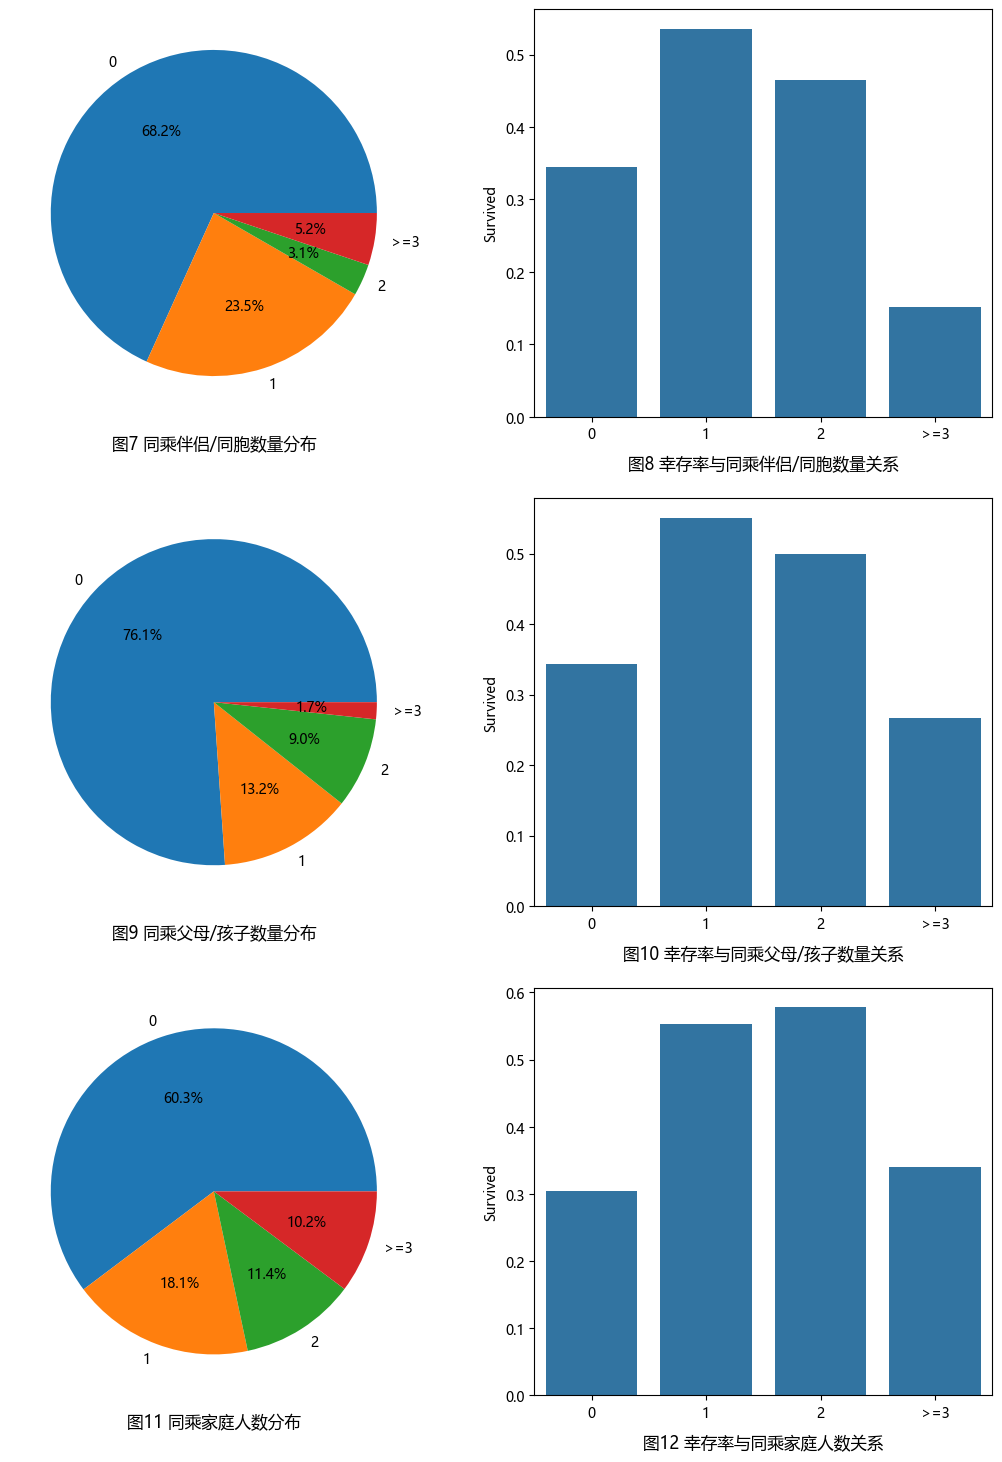

In [46]:
fig,axes=plt.subplots(3,2,figsize=(13,18))
axes[0,0].pie(sp_num,labels=sp_num.index,autopct="%.1f%%")
axes[0,0].set_title("图7 同乘伴侣/同胞数量分布",y=-0.1)
sns.barplot(x=sp_Survived["SibSp1"],y=sp_Survived["Survived"],ax=axes[0,1])
axes[0,1].set_title("图8 幸存率与同乘伴侣/同胞数量关系",y=-0.15)
axes[0,1].set_xlabel("  ")    

axes[1,0].pie(Pa_num,labels=Pa_num.index,autopct="%.1f%%")
axes[1,0].set_title("图9 同乘父母/孩子数量分布",y=-0.1)
sns.barplot(x=Pa_Survived["Parch1"],y=Pa_Survived["Survived"],ax=axes[1,1])
axes[1,1].set_title("图10 幸存率与同乘父母/孩子数量关系",y=-0.15)
axes[1,1].set_xlabel("  ")    

axes[2,0].pie(Fa_num,labels=Pa_num.index,autopct="%.1f%%")
axes[2,0].set_title("图11 同乘家庭人数分布",y=-0.1)
sns.barplot(x=Fa_Survived["FamilyNum1"],y=Fa_Survived["Survived"],ax=axes[2,1])
axes[2,1].set_title("图12 幸存率与同乘家庭人数关系",y=-0.15)
axes[2,1].set_xlabel("  ")    

#### 6.3.1 幸存率与同乘数量之间关系：
1. 图7、图9、图11可知，单独乘坐人群最多，其次是1位同乘，且与一位伴侣/同胞同乘概率高于一位父母/孩子同乘；
2. 图8、图10、图12可知，随着同乘人数增加，幸存率先增加后降低。其中，同乘1-2名时，幸存率最高。这可能时2-3人团队在危机中决策迅速、凝聚力强导致的。


### 6.4 幸存率与消费之间关系
观察数据发现，同票的消费相同，存在多人共用一票的情况，我们将个人消费额度（Fare/用票总人数）作为分析对象

In [47]:
clean_Fare=clean_data.copy()

In [48]:
clean_Fare["Fare"]=clean_Fare["Fare"]/(clean_Fare["FamilyNum"]+1)

In [49]:
clean_Fare[(clean_Fare["Fare"]>80)&(clean_Fare["Fare"]<160)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.000000,0,1,PC 17558,123.76040,B58 B60,C,1
195,196,1,1,"Lurette, Miss. Elise",female,58.000000,0,0,PC 17569,146.52080,B80,C,0
257,258,1,1,"Cherry, Miss. Gladys",female,30.000000,0,0,110152,86.50000,B77,S,0
269,270,1,1,"Bissette, Miss. Amelia",female,35.000000,0,0,PC 17760,135.63330,C99,S,0
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.000000,0,1,PC 17558,123.76040,B58 B60,C,1
306,307,1,1,"Fleming, Miss. Margaret",female,29.699118,0,0,17421,110.88330,NaN,C,0
310,311,1,1,"Hays, Miss. Margaret Bechstein",female,24.000000,0,0,11767,83.15830,C54,C,0
325,326,1,1,"Young, Miss. Marie Grice",female,36.000000,0,0,PC 17760,135.63330,C32,C,0
337,338,1,1,"Burns, Miss. Elizabeth Margaret",female,41.000000,0,0,16966,134.50000,E40,C,0
373,374,0,1,"Ringhini, Mr. Sante",male,22.000000,0,0,PC 17760,135.63330,NaN,C,0


In [50]:
clean_Fare["Fare"].describe()

count    891.000000
mean      19.916375
std       35.841257
min        0.000000
25%        7.250000
50%        8.300000
75%       23.666667
max      512.329200
Name: Fare, dtype: float64

In [51]:
clean_Fare_male	=clean_Fare[clean_Fare["Sex"]=="male"]
clean_Fare_female	=clean_Fare[clean_Fare["Sex"]=="female"]

Text(0.5, -0.2, '图14 乘客费用分布密度与性别关系')

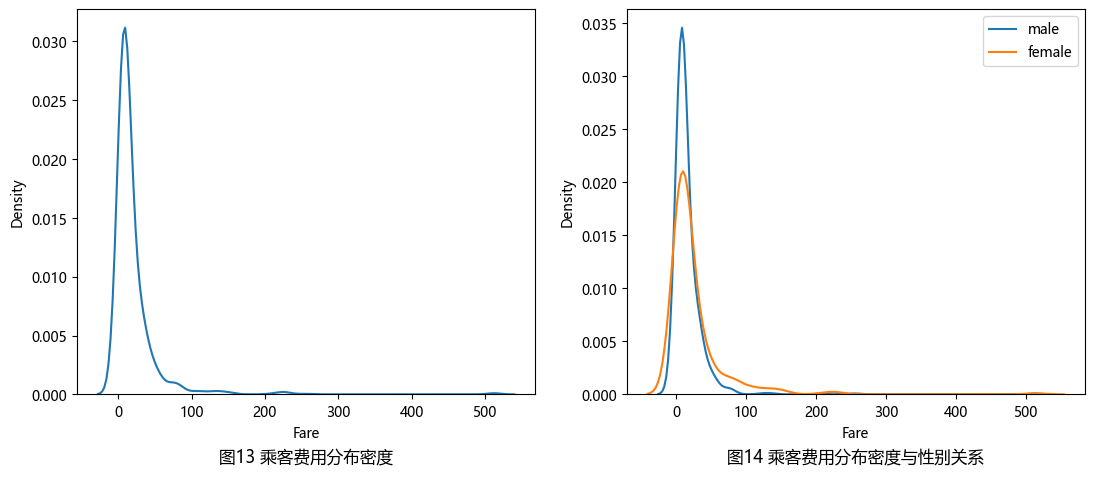

In [52]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.kdeplot(clean_Fare["Fare"],ax=axes[0])
axes[0].set_title("图13 乘客费用分布密度",y=-0.2) 
sns.kdeplot(clean_Fare_male ["Fare"], label="male",ax=axes[1])
sns.kdeplot(clean_Fare_female ["Fare"], label="female",ax=axes[1])
plt.legend()
axes[1].set_title("图14 乘客费用分布密度与性别关系",y=-0.2)

In [53]:
clean_Fare_male["Fare"].describe()

count    577.000000
mean      16.873722
std       30.094180
min        0.000000
25%        7.312500
50%        8.050000
75%       15.045800
max      512.329200
Name: Fare, dtype: float64

In [54]:
clean_Fare_female["Fare"].describe()

count    314.000000
mean      25.507493
std       44.018319
min        1.132143
25%        7.229200
50%        9.750000
75%       26.550000
max      512.329200
Name: Fare, dtype: float64

In [55]:
bins=[0,10,20,40,80,1000]
label=["0-10","10-20","20-40","40-80",">=80"]
clean_Fare["Fare/$"]=pd.cut(clean_Fare["Fare"],bins,labels=label,right=False)
Fare_Survived=clean_Fare.groupby("Fare/$")["Survived"].mean()
Fare_Survived=Fare_Survived.reset_index()
Fare_Survived

,Fare/$,Survived
0,0-10,0.270059
1,10-20,0.435065
2,20-40,0.544118
3,40-80,0.622951
4,>=80,0.862069


In [56]:
Fare_num=clean_Fare.groupby("Fare/$")["PassengerId"].count()
Fare_num

Fare/$
0-10     511
10-20    154
20-40    136
40-80     61
>=80      29
Name: PassengerId, dtype: int64

In [57]:
clean_Fare_male=clean_Fare[clean_Fare["Sex"]=="male"]
bins=[0,10,20,40,80,1000]
label=["0-10","10-20","20-40","40-80",">=80"]
clean_Fare_male["Fare/$"]=pd.cut(clean_Fare_male["Fare"],bins,labels=label,right=False)
Fare_male_Survived=clean_Fare_male.groupby("Fare/$")["Survived"].mean()
Fare_male_Survived=Fare_male_Survived.reset_index()
Fare_male_Survived

,Fare/$,Survived
0,0-10,0.137143
1,10-20,0.130435
2,20-40,0.385417
3,40-80,0.303030
4,>=80,0.333333


In [58]:
Fare_male_num=clean_Fare_male.groupby("Fare/$")["PassengerId"].count()
Fare_male_num

Fare/$
0-10     350
10-20     92
20-40     96
40-80     33
>=80       6
Name: PassengerId, dtype: int64

In [59]:
clean_Fare_female=clean_Fare[clean_Fare["Sex"]=="female"]
bins=[0,10,20,40,80,1000]
label=["0-10","10-20","20-40","40-80",">=80"]
clean_Fare_female["Fare/$"]=pd.cut(clean_Fare_female["Fare"],bins,labels=label,right=False)
Fare_female_Survived=clean_Fare_female.groupby("Fare/$")["Survived"].mean()
Fare_female_Survived=Fare_female_Survived.reset_index()
Fare_female_Survived

,Fare/$,Survived
0,0-10,0.559006
1,10-20,0.887097
2,20-40,0.925000
3,40-80,1.000000
4,>=80,1.000000


In [60]:
Fare_female_num=clean_Fare_female.groupby("Fare/$")["PassengerId"].count()
Fare_female_num

Fare/$
0-10     161
10-20     62
20-40     40
40-80     28
>=80      23
Name: PassengerId, dtype: int64

Text(0.5, -0.1, '图16 女性费用分布')

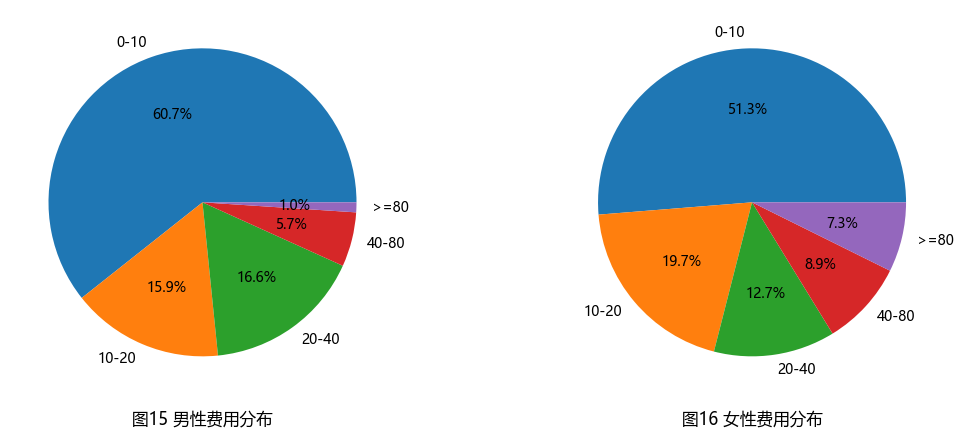

In [61]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].pie(Fare_male_num,labels=Fare_male_num.index,autopct="%.1f%%")
axes[0].set_title("图15 男性费用分布",y=-0.1)
axes[1].pie(Fare_female_num,labels=Fare_female_num.index,autopct="%.1f%%")
axes[1].set_title("图16 女性费用分布",y=-0.1)

Text(0.5, -0.2, '图18 幸存率与费用关系')

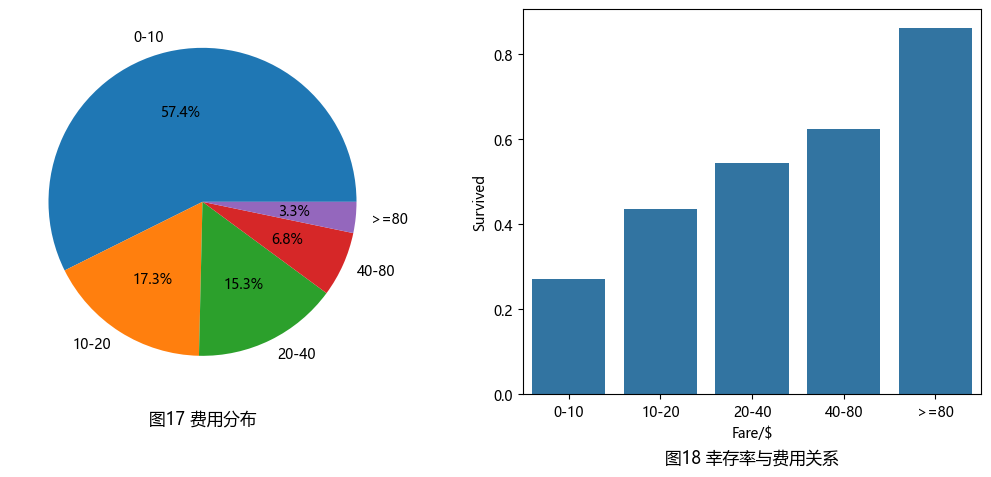

In [62]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].pie(Fare_num,labels=Fare_num.index,autopct="%.1f%%")
axes[0].set_title("图17 费用分布",y=-0.1)
sns.barplot(x=Fare_Survived["Fare/$"],y=Fare_Survived["Survived"],ax=axes[1])
axes[1].set_title("图18 幸存率与费用关系",y=-0.2)

In [63]:
Sex_Fare_Survived=clean_Fare.groupby(["Fare/$","Sex"])["Survived"].mean()
Sex_Fare_Survived=Sex_Fare_Survived.reset_index()
Sex_Fare_Survived

,Fare/$,Sex,Survived
0,0-10,female,0.559006
1,0-10,male,0.137143
2,10-20,female,0.887097
3,10-20,male,0.130435
4,20-40,female,0.925000
5,20-40,male,0.385417
6,40-80,female,1.000000
7,40-80,male,0.303030
8,>=80,female,1.000000
9,>=80,male,0.333333


Text(0.5, -0.2, '图19 幸存率与费用/性别关系')

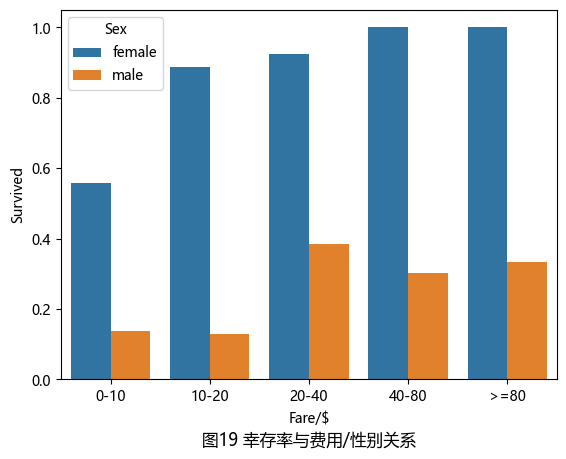

In [64]:
sns.barplot(Sex_Fare_Survived,x=Sex_Fare_Survived["Fare/$"],y=Sex_Fare_Survived["Survived"],hue="Sex")
plt.title("图19 幸存率与费用/性别关系",y=-0.2)

#### 6.4.1 消费分布关系：
1. 图13-16可知，女性消费能力强于男性，女性消费平均值为`25.5$`,高于男性（男性平均值为`16.5\$`），但两者消费的中位数相差不大；
2. 图13-16可知，女性乘客中的高消费群体（>80$）占比明显高于男性乘客中的高消费群体占比。

#### 6.4.2 幸存率与消费之间关系：
1. 图17可知，乘客的消费主要集中在0-10\$，约占总全体的57.4%；
2. 图18可知，幸存率与消费大小成正相关。
3. 图19可知，男性消费全体中，消费大于`20$`群体的存活率约为消费低于`20$`的群体的两倍，

### 6.5 探索数据结论
预计各因数对幸存率影响的权重：性别  >  舱位等级  >  消费  >  年龄  >  家庭规模

In [65]:
clean=clean_Fare.copy()
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    str     
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
 12  FamilyNum    891 non-null    int64   
 13  Fare/$       891 non-null    category
dtypes: category(4), float64(2), int64(4), str(4)
memory usage: 73.7 KB


In [66]:
clean["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### 6.6 数据调整
- PassengerId\Name、Ticket、Cabin 为个人特性，对幸存率影响较小，故删除；
- Fare的内容改为Fare/$内容，并删除`Fare/$`；
- Embarked缺失的内容用最高出现频率的内容替代("S")。

In [67]:
clean=clean_Fare.copy()
clean=clean.drop(["PassengerId","Name","Ticket","Cabin","Fare/$"],axis=1)
clean["Embarked"]=clean["Embarked"].fillna("S")

In [68]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Survived   891 non-null    int64   
 1   Pclass     891 non-null    category
 2   Sex        891 non-null    category
 3   Age        891 non-null    float64 
 4   SibSp      891 non-null    int64   
 5   Parch      891 non-null    int64   
 6   Fare       891 non-null    float64 
 7   Embarked   891 non-null    category
 8   FamilyNum  891 non-null    int64   
dtypes: category(3), float64(2), int64(4)
memory usage: 44.8 KB


## 7. 逻辑回归实现

<Axes: >

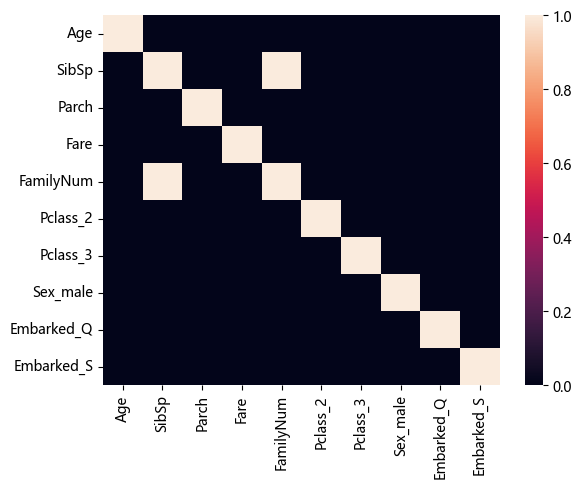

In [69]:
clean=pd.get_dummies(clean,columns=["Pclass","Sex","Embarked"],dtype=int,drop_first=True)
y=clean["Survived"]
x=clean.drop("Survived",axis=1)
sns.heatmap(x.corr().abs()>0.8)

heatmap发现，FamilyNum与SibSp强相关，这里删除SibSp

<Axes: >

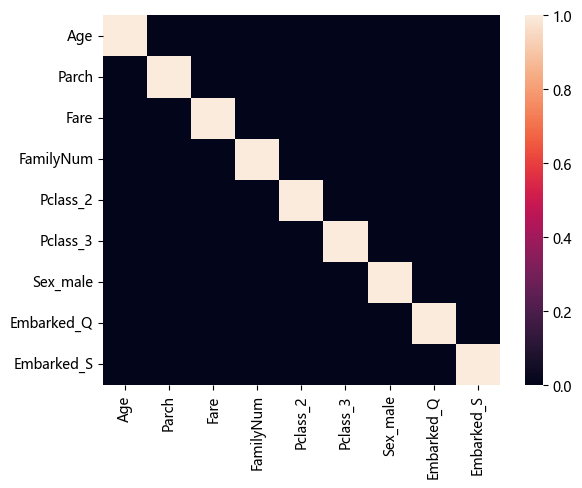

In [70]:
x=x.drop("SibSp",axis=1)
sns.heatmap(x.corr().abs()>0.8)

In [71]:
x=sm.add_constant(x)
x

,const,Age,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,1.0,22.000000,0,3.62500,1,0,1,1,0,1
1,1.0,38.000000,0,35.64165,1,0,0,0,0,0
2,1.0,26.000000,0,7.92500,0,0,1,0,0,1
3,1.0,35.000000,0,26.55000,1,0,0,0,0,1
4,1.0,35.000000,0,8.05000,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,1.0,27.000000,0,13.00000,0,1,0,1,0,1
887,1.0,19.000000,0,30.00000,0,0,0,0,0,1
888,1.0,29.699118,2,5.86250,3,0,1,0,0,1
889,1.0,26.000000,0,30.00000,0,0,0,1,0,0


In [72]:
result=sm.Logit(y,x).fit()

Optimization terminated successfully.
         Current function value: 0.440393
         Iterations 6


In [73]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      881
Method:                           MLE   Df Model:                            9
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.3387
Time:                        14:35:45   Log-Likelihood:                -392.39
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 5.453e-81
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1649      0.473      8.811      0.000       3.238       5.091
Age           -0.0392      0.008     -4.989      0.000      -0.055      -0.024
Parch          0.2343      0.180      1.301      0.193      -0.119       0.587
Fare           0.0022      0.003      0.679      0.497      -0.004       0.009
FamilyNum     -0.3048      0.108     -2.813      0.005      -0.517      -0.092
Pclass_2      -0.9785      0.289     -3.385      0.001      -1.545      -0.412
Pclass_3      -2.2167      0.283     -7.842      0.000      -2.771      -1.663
Sex_male      -2.7180      0.201    -13.516      0.000      -3.112      -2.324
Embarked_Q    -0.0274      0.383     -0.072      0.943      -0.777       0.723
Embarked_S    -0.4495      0.240     -1.876      0.061      -0.919       0.020
==============================================================================
"""

Parch、Fare、Embarked_Q、Embarked_S的P值大于0.05，删除

In [74]:
x=x.drop(["Parch","Fare","Embarked_Q","Embarked_S"],axis=1)
x

,const,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,22.000000,1,0,1,1
1,1.0,38.000000,1,0,0,0
2,1.0,26.000000,0,0,1,0
3,1.0,35.000000,1,0,0,0
4,1.0,35.000000,0,0,1,1
...,...,...,...,...,...,...
886,1.0,27.000000,0,1,0,1
887,1.0,19.000000,0,0,0,0
888,1.0,29.699118,3,0,1,0
889,1.0,26.000000,0,0,0,1


<Axes: >

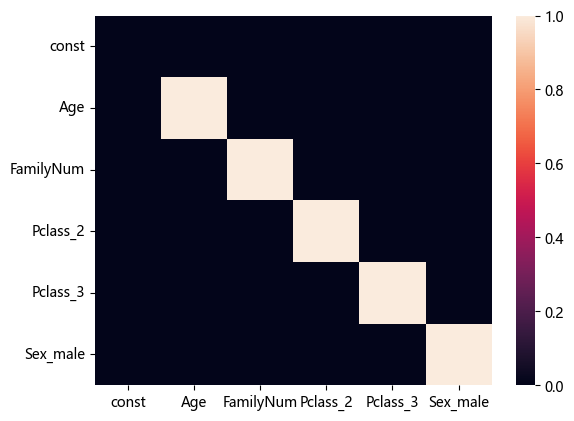

In [75]:
sns.heatmap(x.corr().abs()>0.8)

In [76]:
result=sm.Logit(y,x).fit()

Optimization terminated successfully.
         Current function value: 0.444623
         Iterations 6


In [77]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.3323
Time:                        14:35:46   Log-Likelihood:                -396.16
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 4.927e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0620      0.404     10.049      0.000       3.270       4.854
Age           -0.0395      0.008     -5.065      0.000      -0.055      -0.024
FamilyNum     -0.2186      0.065     -3.383      0.001      -0.345      -0.092
Pclass_2      -1.1798      0.261     -4.518      0.000      -1.692      -0.668
Pclass_3      -2.3458      0.242     -9.676      0.000      -2.821      -1.871
Sex_male      -2.7854      0.198    -14.069      0.000      -3.173      -2.397
==============================================================================
"""

In [78]:
x

,const,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,22.000000,1,0,1,1
1,1.0,38.000000,1,0,0,0
2,1.0,26.000000,0,0,1,0
3,1.0,35.000000,1,0,0,0
4,1.0,35.000000,0,0,1,1
...,...,...,...,...,...,...
886,1.0,27.000000,0,1,0,1
887,1.0,19.000000,0,0,0,0
888,1.0,29.699118,3,0,1,0
889,1.0,26.000000,0,0,0,1


查看预测数据情况，并将预测集变量与x保持一致

In [79]:
new_observation.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [80]:
x1=new_observation.drop(["PassengerId","Name","SibSp","Parch","Ticket","Fare","Embarked","Cabin"],axis=1)
x1["FamilyNum"]=new_observation["SibSp"]+new_observation["Parch"]
x1.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Pclass     418 non-null    int64  
 1   Sex        418 non-null    str    
 2   Age        332 non-null    float64
 3   FamilyNum  418 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 13.2 KB


用平均填充Age

In [81]:
x1["Age"]=x1["Age"].fillna(x1["Age"].mean())
x1.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Pclass     418 non-null    int64  
 1   Sex        418 non-null    str    
 2   Age        418 non-null    float64
 3   FamilyNum  418 non-null    int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 13.2 KB


In [82]:
x1["Pclass"]=x1["Pclass"].astype("category")
x1["Sex"]=pd.Categorical(x1["Sex"],categories=["female","male"])
x1["Pclass"]=pd.Categorical(x1["Pclass"],categories=["1","2","3"])
x1=pd.get_dummies(x1,columns=["Pclass","Sex"],dtype=int,drop_first=True)
x1=sm.add_constant(x1)
x1

C:\Users\ZhuanZ（无密码）\AppData\Local\Temp\ipykernel_1432\2649252940.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x1["Pclass"]=pd.Categorical(x1["Pclass"],categories=["1","2","3"])


,const,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,34.50000,0,0,0,1
1,1.0,47.00000,1,0,0,0
2,1.0,62.00000,0,0,0,1
3,1.0,27.00000,0,0,0,1
4,1.0,22.00000,2,0,0,0
...,...,...,...,...,...,...
413,1.0,30.27259,0,0,0,1
414,1.0,39.00000,0,0,0,0
415,1.0,38.50000,0,0,0,1
416,1.0,30.27259,0,0,0,1


In [83]:
new_observation["Survived"]=result.predict(x1)

In [84]:
new_observation.tail(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
408,1300,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q,0.946158
409,1301,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,0.970865
410,1302,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q,0.946158
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,0.915447
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,0.950552
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0.520230
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.925647
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0.439306
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0.520230
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C,0.411858
